# PaddleOCR: промышленное OCR от Baidu

В предыдущих блокнотах мы изучили два подхода:
- **Tesseract** — классика, отлично работает с чистыми документами, но беспомощен на фотографиях
- **EasyOCR** — modern deep learning, справляется с реальными сценами, но медленный на CPU

**PaddleOCR** это промышленная система от Baidu, которая объединяет лучшее из обоих миров. Она используется в production-системах Baidu с нагрузкой в миллиарды запросов и при этом способна работать даже на мобильных устройствах.


## Как устроен PaddleOCR?

PaddleOCR это трёхэтапный pipeline, каждый этап независимо заменяем:

### Этап 1: Детекция текста
По умолчанию используется **DB-Net** (Differentiable Binarization) — тот самый, который мы разбирали в блоке по детекции текста. DB-Net предсказывает карту вероятностей принадлежности к тексту, а адаптивный порог бинаризации обучается вместе с сетью. Это даёт точные полигоны даже для мелкого и размытого текста.

### Этап 2: Классификация угла (опционально)
Перед распознаванием PaddleOCR может определить, повёрнут ли вырезанный регион на 180 градусов, и исправить это автоматически. Отдельная лёгкая сеть для классификации угла.

### Этап 3: Распознавание текста
Используется **SVTR** (Scene Text Recognition with a Single Visual Model) или **CRNN** в зависимости от конфигурации. Вырезанные регионы выпрямляются, нормализуются и подаются в рекуррентную сеть.

### Два режима: lite vs server

| Параметр | Lite (mobile) | Server |
|---|---|---|
| Backbone детектора | MobileNetV3 | ResNet50 |
| Размер модели | ~3 МБ | ~100 МБ |
| Скорость | Очень высокая | Умеренная |
| Точность | Хорошая | Отличная |
| Назначение | Мобильные / edge | Сервер / облако |

## В этом блокноте мы:
1. Установим PaddleOCR и разберёмся с конфигурациями
2. Распознаем текст на простом изображении
3. Поработаем с многоязычным текстом
4. Обработаем реальный чек
5. Сравним скорость работы
6. Разберём параметры детекции и их влияние
7. Посмотрим работу на "сложных" примерах
8. Сдеалаем анализ структуры документа

Полезные ссылки:
- [Документация PaddleOCR](https://paddlepaddle.github.io/PaddleOCR/)
- [GitHub репозиторий](https://github.com/PaddlePaddle/PaddleOCR)
- [Список поддерживаемых языков](https://paddlepaddle.github.io/PaddleOCR/en/ppocr/blog/multi_languages.html)

## Установка

Установим фиксированные версии, которые хоршо работают в colab

In [ ]:
# Устанавливаем PaddlePaddle
!pip install -q paddlepaddle==2.6.2
# Устанавливаем PaddleOCR
!pip install -q paddleocr==2.7.3
# Вспомогательные библиотеки
!pip install -q opencv-python matplotlib pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.0/780.0 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install "numpy<2.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 22.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-py

In [ ]:
from paddleocr import PaddleOCR
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from pathlib import Path

import paddle
print(f"PaddlePaddle version: {paddle.__version__}")

PaddlePaddle version: 2.6.2


In [ ]:
!apt-get update -qq
!apt-get install -qq fonts-dejavu fonts-liberation

# Проверка установленных шрифтов
!fc-list | grep -i dejavu | head -5

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-dejavu-core.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-dejavu-core_2.37-2build1_all.deb ...
Unpacking fonts-dejavu-core (2.37-2build1) ...
Selecting previously unselected package fonts-dejavu-extra.
Preparing to unpack .../fonts-dejavu-extra_2.37-2build1_all.deb ...
Unpacking fonts-dejavu-extra (2.37-2build1) ...
Selecting previously unselected package fonts-dejavu.
Preparing to unpack .../fonts-dejavu_2.37-2build1_all.deb ...
Unpacking fonts-dejavu (2.37-2build1) ...
Setting up fonts-dejavu-core (2.37-2build1) ...
Setting up fonts-dejavu-extra (2.37-2build1) ...
Setting up fonts-dejavu (2.37-2build1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts/truetype/dejavu

## Инициализация PaddleOCR

`PaddleOCR` — главный класс библиотеки. Основные параметры при создании:

- `use_angle_cls=True` — включить классификатор угла поворота (рекомендуется)
- `lang` — язык: `'en'`, `'ru'`, `'ch'` (китайский), `'japan'` и т.д.
- `use_gpu=False` — использовать ли GPU
- `det_model_dir` — путь к своей модели детектора (если не нужна автозагрузка)
- `rec_model_dir` — путь к своей модели распознавания
- `show_log=False` — отключить подробные логи PaddlePaddle

In [ ]:
# Создаём OCR для английского языка
# При первом запуске скачает модели (~50 MB)
ocr = PaddleOCR(
    use_angle_cls=True,
    lang='en',
    use_gpu=False,
    show_log=False
)
print("PaddleOCR инициализирован")

download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 4.00M/4.00M [00:00<00:00, 10.4MiB/s]


download https://paddleocr.bj.bcebos.com/PP-OCRv4/english/en_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/en/en_PP-OCRv4_rec_infer/en_PP-OCRv4_rec_infer.tar


100%|██████████| 10.2M/10.2M [00:00<00:00, 21.6MiB/s]


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2.19M/2.19M [00:00<00:00, 6.53MiB/s]


PaddleOCR инициализирован


## Первый запуск: простое изображение

Начнём с того же синтетического изображения, что и в Tesseract/EasyOCR блокнотах так можно сравнить результаты напрямую.

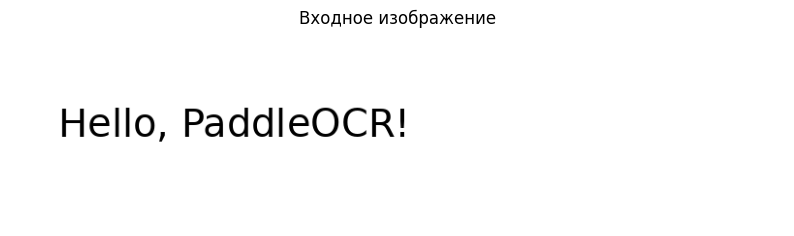

In [ ]:
img = Image.new('RGB', (800, 200), color='white')
draw = ImageDraw.Draw(img)

font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 40)
draw.text((50, 70), "Hello, PaddleOCR!", fill='black', font=font)
img.save('simple.png')

plt.figure(figsize=(10, 3))
plt.imshow(img)
plt.axis('off')
plt.title('Входное изображение')
plt.show()

In [ ]:
results = ocr.ocr('simple.png', cls=True)

print("Результат ocr():")
# results — список страниц, results[0] — первая страница
for line in results[0]:
    bbox, (text, confidence) = line
    print(f"  Текст:       '{text}'")
    print(f"  Уверенность: {confidence:.2%}")
    print(f"  bbox:        {bbox}")
    print()

Результат ocr():
  Текст:       'Hello, PaddleOcR!'
  Уверенность: 94.92%
  bbox:        [[53.0, 78.0], [409.0, 78.0], [409.0, 109.0], [53.0, 109.0]]



### Формат вывода ocr()

PaddleOCR возвращает список страниц. Каждая страница это список строк. Каждая строка:
```
[bbox, (text, confidence)]
```
где `bbox` — четыре точки `[[x1,y1], [x2,y2], [x3,y3], [x4,y4]]` по часовой стрелке.

Обратите внимание на вложенность: `results[0]` — это первая (и обычно единственная) страница. Это сделано для поддержки PDF-документов с несколькими страницами.

## Визуализация результатов

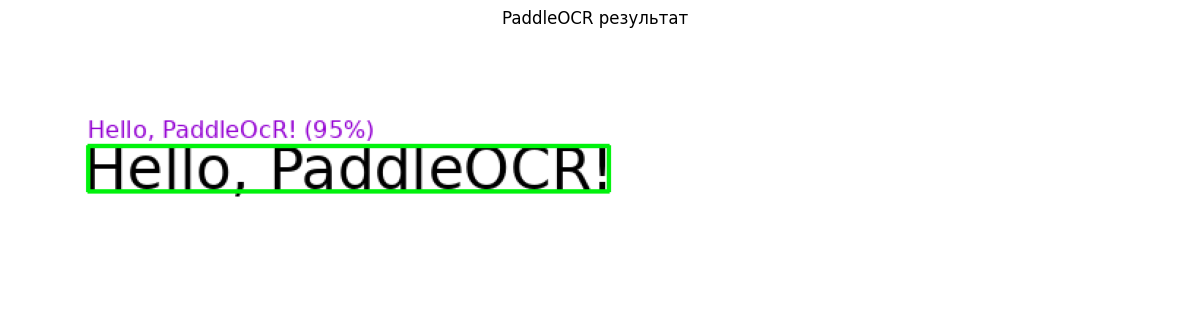

In [ ]:
def visualize_paddle(image_path, results, font=font, title='PaddleOCR результат', figsize=(12, 8)):
    """Отрисовывает bbox и текст поверх изображения."""
    img     = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(img_rgb)
    draw    = ImageDraw.Draw(pil_img)

    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 16)

    if results[0] is None:
        print("Текст не найден")
        return

    for line in results[0]:
        bbox, (text, conf) = line
        pts        = np.array(bbox, dtype=np.int32)
        bbox_color = (0, int(255 * conf), int(255 * (1 - conf)))
        text_color = (148, 0, 211)

        vis_np  = np.array(pil_img)
        cv2.polylines(vis_np, [pts], isClosed=True, color=bbox_color, thickness=2)
        pil_img = Image.fromarray(vis_np)
        draw    = ImageDraw.Draw(pil_img)

        label = f"{text} ({conf:.0%})"
        x, y  = pts[0]
        draw.text((x, max(y - 20, 0)), label, fill=text_color, font=font)

    plt.figure(figsize=figsize)
    plt.imshow(pil_img)
    plt.axis('off')
    plt.title(title)
    plt.tight_layout()
    plt.show()

visualize_paddle('simple.png', results, 'Простое изображение')

## Многоязычное распознавание

В отличие от EasyOCR, в PaddleOCR **нельзя** передать несколько языков одновременно в один Reader, для каждого языка нужна отдельная модель распознавания. Это ограничение архитектуры: каждая модель заточена под конкретный алфавит.

Но можно создать несколько OCR-объектов или использовать специальные мультиязычные модели (`latin`, `arabic`, `cyrillic` и т.д.).

In [ ]:
# Создаём отдельные OCR для разных языков
ocr_en = PaddleOCR(use_angle_cls=True, lang='en', use_gpu=False, show_log=False)
ocr_ru = PaddleOCR(use_angle_cls=True, lang='ru', use_gpu=False, show_log=False)
print("OCR для EN и RU созданы")

download https://paddleocr.bj.bcebos.com/PP-OCRv3/multilingual/Multilingual_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/ml/Multilingual_PP-OCRv3_det_infer/Multilingual_PP-OCRv3_det_infer.tar


100%|██████████| 3.85M/3.85M [00:08<00:00, 452kiB/s]


download https://paddleocr.bj.bcebos.com/PP-OCRv3/multilingual/cyrillic_PP-OCRv3_rec_infer.tar to /root/.paddleocr/whl/rec/cyrillic/cyrillic_PP-OCRv3_rec_infer/cyrillic_PP-OCRv3_rec_infer.tar


100%|██████████| 9.98M/9.98M [00:23<00:00, 417kiB/s]


OCR для EN и RU созданы


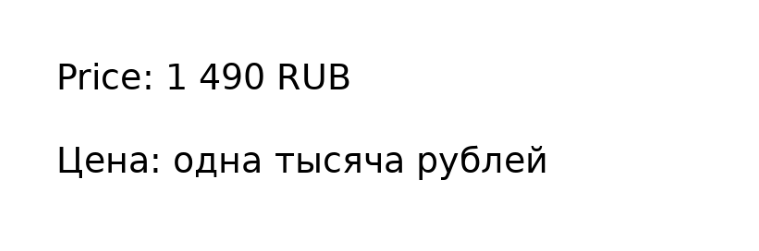

In [ ]:
# Создаём двуязычное изображение (то же что в EasyOCR блокноте)
img = Image.new('RGB', (800, 250), color='white')
draw = ImageDraw.Draw(img)

font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 38)

draw.text((50, 50),  "Price: 1 490 RUB",         fill='black', font=font)
draw.text((50, 140), "Цена: одна тысяча рублей",  fill='black', font=font)
img.save('multilang.png')

plt.figure(figsize=(10, 3))
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
# Запускаем оба OCR и объединяем результаты
res_en = ocr_en.ocr('multilang.png', cls=True)
res_ru = ocr_ru.ocr('multilang.png', cls=True)

print("EN модель:")
for line in res_en[0]:
    _, (text, conf) = line
    print(f"  [{conf:.0%}] {text}")

print("\nRU модель:")
for line in res_ru[0]:
    _, (text, conf) = line
    print(f"  [{conf:.0%}] {text}")

EN модель:
  [97%] Price: 1 490 RUB
  [85%] eha: ohha Tbicaya py6nen

RU модель:
  [98%] Price!
  [97%] I
  [81%] 49о
  [92%] RUB
  [74%] Leнa:
  [92%] ено
  [95%] тысяча
  [100%] рублей


Как видно из простого примера русская модель PaddleOCR (lang='ru') заметно уступает по качеству английской и китайской моделям. Она путает визуально
похожие символы, например Ц с L и выдает плохое качество распознавания.

Для русскоязычных текстов лучше использовать EasyOCR и Tesseract, а PaddleOCR силён на китайском, английском и японском
именно под эти языки он активно развивается и тестируется.

## Предобработка изображений

DB-Net в PaddleOCR довольно устойчив к шуму на изображениях, потому что  обучен на сложных примерах, чаще всего предварительная обработка не требуется, например:

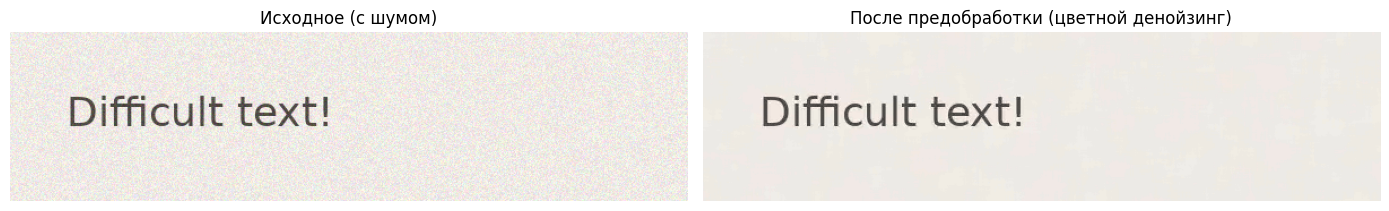

In [ ]:
# Создаём изображение с шумом и низким контрастом
img = Image.new('RGB', (600, 150), color=(240, 235, 230))
draw = ImageDraw.Draw(img)
font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 36)

draw.text((50, 50), "Difficult text!", fill=(80, 75, 70), font=font)
img_array = np.array(img)

noise = np.random.randint(0, 40, img_array.shape, dtype=np.uint8)
noisy = np.clip(img_array.astype(np.int32) + noise - 20, 0, 255).astype(np.uint8)
cv2.imwrite('noisy.png', cv2.cvtColor(noisy, cv2.COLOR_RGB2BGR))

# Предобработка цветной денойзинг
denoised_color = cv2.fastNlMeansDenoisingColored(
    cv2.cvtColor(noisy, cv2.COLOR_RGB2BGR),
    h=10, hColor=10,
    templateWindowSize=7,
    searchWindowSize=21
)
enhanced = cv2.cvtColor(denoised_color, cv2.COLOR_BGR2RGB)
cv2.imwrite('enhanced.png', cv2.cvtColor(enhanced, cv2.COLOR_RGB2BGR))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(noisy)
axes[0].set_title('Исходное (с шумом)')
axes[0].axis('off')
axes[1].imshow(enhanced)
axes[1].set_title('После предобработки (цветной денойзинг)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
results_noisy    = ocr_en.ocr('noisy.png',    cls=True)
results_enhanced = ocr_en.ocr('enhanced.png', cls=True)

print("Без предобработки:")
for line in results_noisy[0]:
    _, (text, conf) = line
    print(f"  [{conf:.0%}] {text}")

print("\nПосле предобработки:")
for line in results_enhanced[0]:
    _, (text, conf) = line
    print(f"  [{conf:.0%}] {text}")

Без предобработки:
  [100%] Difficult text!

После предобработки:
  [99%] Difficult text!


Видно, что в отличии от EasyOCR предобработка не только не помогает, а даже ухудшает качество

## Обработка чека

Обработаем тот же синтетический чек, что и в предыдущих блокнотах. Это позволит сравнить три инструмента на одинаковых данных, хоть мы и знаем что PaddleOCR должен хуже справиться с кириллицей.

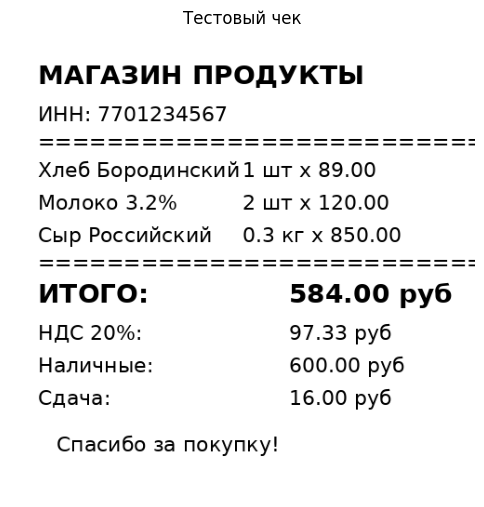

In [ ]:
# Создаём синтетический чек (идентично Tesseract и EasyOCR блокнотам)
img = Image.new('RGB', (500, 500), color='white')
draw = ImageDraw.Draw(img)

font_large = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 28)
font_small = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 22)

lines = [
    ("МАГАЗИН ПРОДУКТЫ",   30,  30, font_large),
    ("ИНН: 7701234567",    30,  75, font_small),
    ("="*35,               30, 105, font_small),
    ("Хлеб Бородинский",   30, 135, font_small),
    ("1 шт x 89.00",      250, 135, font_small),
    ("Молоко 3.2%",        30, 170, font_small),
    ("2 шт x 120.00",     250, 170, font_small),
    ("Сыр Российский",     30, 205, font_small),
    ("0.3 кг x 850.00",   250, 205, font_small),
    ("="*35,               30, 235, font_small),
    ("ИТОГО:",             30, 265, font_large),
    ("584.00 руб",        300, 265, font_large),
    ("НДС 20%:",           30, 310, font_small),
    ("97.33 руб",         300, 310, font_small),
    ("Наличные:",          30, 345, font_small),
    ("600.00 руб",        300, 345, font_small),
    ("Сдача:",             30, 380, font_small),
    ("16.00 руб",         300, 380, font_small),
    ("Спасибо за покупку!", 50, 430, font_small),
]

for text, x, y, font in lines:
    draw.text((x, y), text, fill='black', font=font)

img.save('receipt.png')

plt.figure(figsize=(6, 7))
plt.imshow(img)
plt.axis('off')
plt.title('Тестовый чек')
plt.show()

Найдено текстовых регионов: 38

Распознанный текст:
  [98%] магазин
  [98%] продукты
  [86%] ИHH!
  [81%] ђозза5ђ
  [60%] LLLLLLLLLLLLLLLLLE
  [98%] Хлеб
  [94%] Бородинский
  [89%] шт
  [84%] х
  [86%] 39.00
  [99%] Молоко
  [87%] 3.200
  [91%] шт
  [87%] х
  [87%] 120.00
  [99%] Сыр
  [100%] Российский
  [97%] O.3
  [93%] кг
  [93%] х
  [75%] 850.0о
  [67%] ееееее
  [72%] иTOгO:
  [92%] 534.оо
  [100%] руб
  [89%] ндс
  [82%] 200o!
  [67%] 97:33
  [98%] руб
  [99%] Hаличные
  [66%] 6оо.0о
  [92%] руб
  [91%] Cдaчa!
  [97%] 16.00
  [98%] руб
  [98%] Спасибо
  [98%] за
  [90%] пokynky!


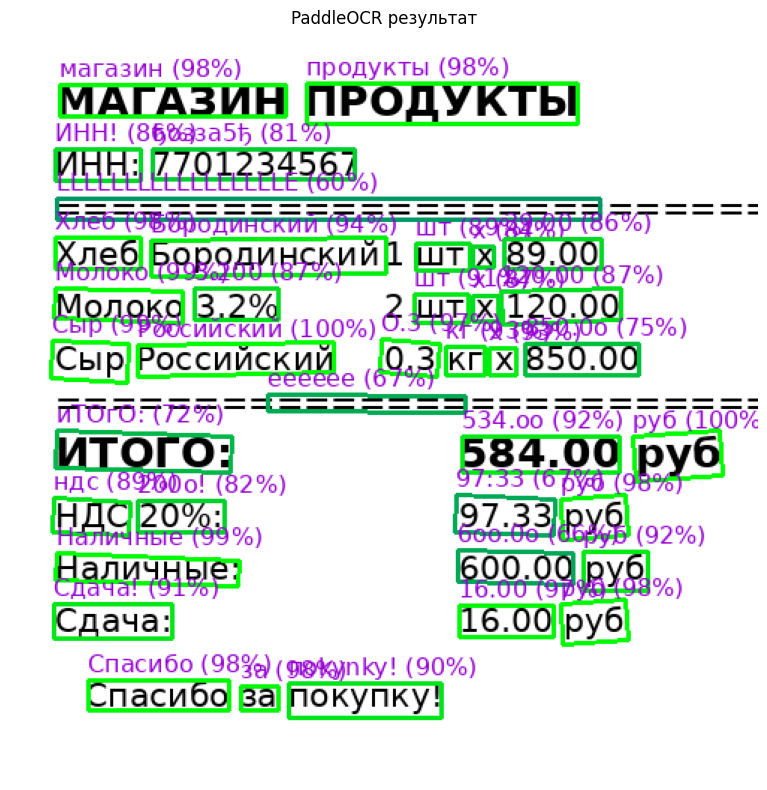

In [ ]:
results = ocr_ru.ocr('receipt.png', cls=True)

print(f"Найдено текстовых регионов: {len(results[0])}\n")
print("Распознанный текст:")
for line in results[0]:
    _, (text, conf) = line
    print(f"  [{conf:.0%}] {text}")

visualize_paddle('receipt.png', results, f'Чек: {len(results[0])} регионов')

## Параметры детекции и их влияние

PaddleOCR даёт прямой доступ к параметрам DB-Net детектора:

| Параметр | По умолчанию | Описание |
|---|---|---|
| `det_db_thresh` | 0.3 | Порог бинаризации prob map (аналог PROB_THRESH в нашем DB-Net коде) |
| `det_db_box_thresh` | 0.5 | Минимальный средний score внутри найденного контура |
| `det_db_unclip_ratio` | 1.6 | Коэффициент расширения контура (unclip) |
| `det_db_score_mode` | 'fast' | 'fast' = avg по bbox, 'slow' = avg по полигону |
| `det_limit_side_len` | 960 | Максимальная сторона изображения перед детекцией |
| `rec_batch_num` | 6 | Количество регионов в одном батче распознавания |
| `drop_score` | 0.5 | Фильтрация результатов с уверенностью ниже этого порога |

Первые три параметра это именно те, с которыми мы работали в блокноте по DB-Net.

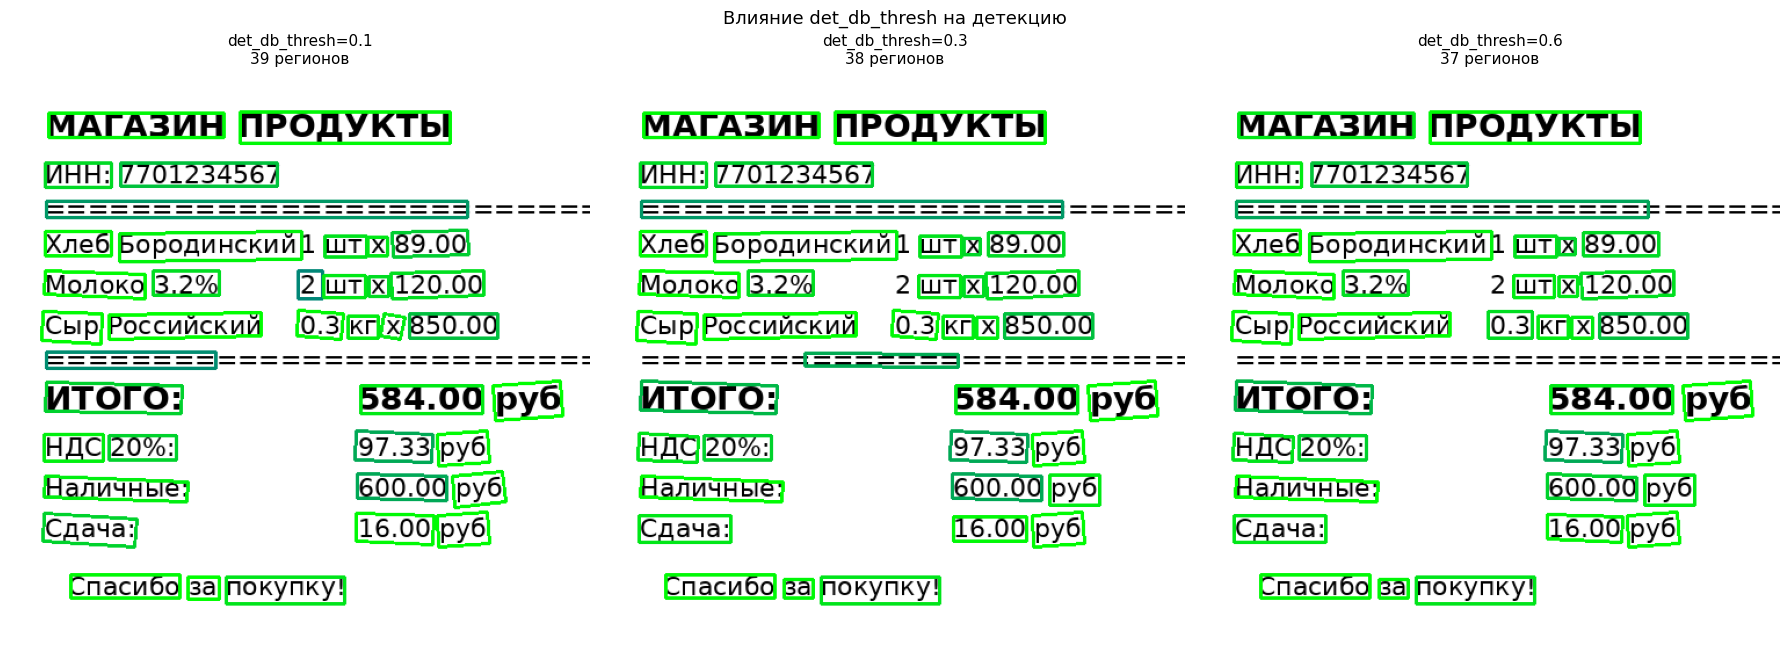

In [ ]:
# Сравниваем разные пороги det_db_thresh
img_bgr = cv2.imread('receipt.png')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, thresh in zip(axes, [0.1, 0.3, 0.6]):
    ocr_tmp = PaddleOCR(
        use_angle_cls=False, lang='ru', use_gpu=False,
        show_log=False, det_db_thresh=thresh
    )
    res = ocr_tmp.ocr('receipt.png', cls=False)
    vis = img_rgb.copy()

    for line in res[0]:
        bbox, (text, conf) = line
        pts = np.array(bbox, dtype=np.int32)
        color = (0, int(255 * conf), int(255 * (1 - conf)))
        cv2.polylines(vis, [pts], True, color, 2)

    ax.imshow(vis)
    ax.set_title(f'det_db_thresh={thresh}\n{len(res[0])} регионов', fontsize=11)
    ax.axis('off')

plt.suptitle('Влияние det_db_thresh на детекцию', fontsize=13)
plt.tight_layout()
plt.show()

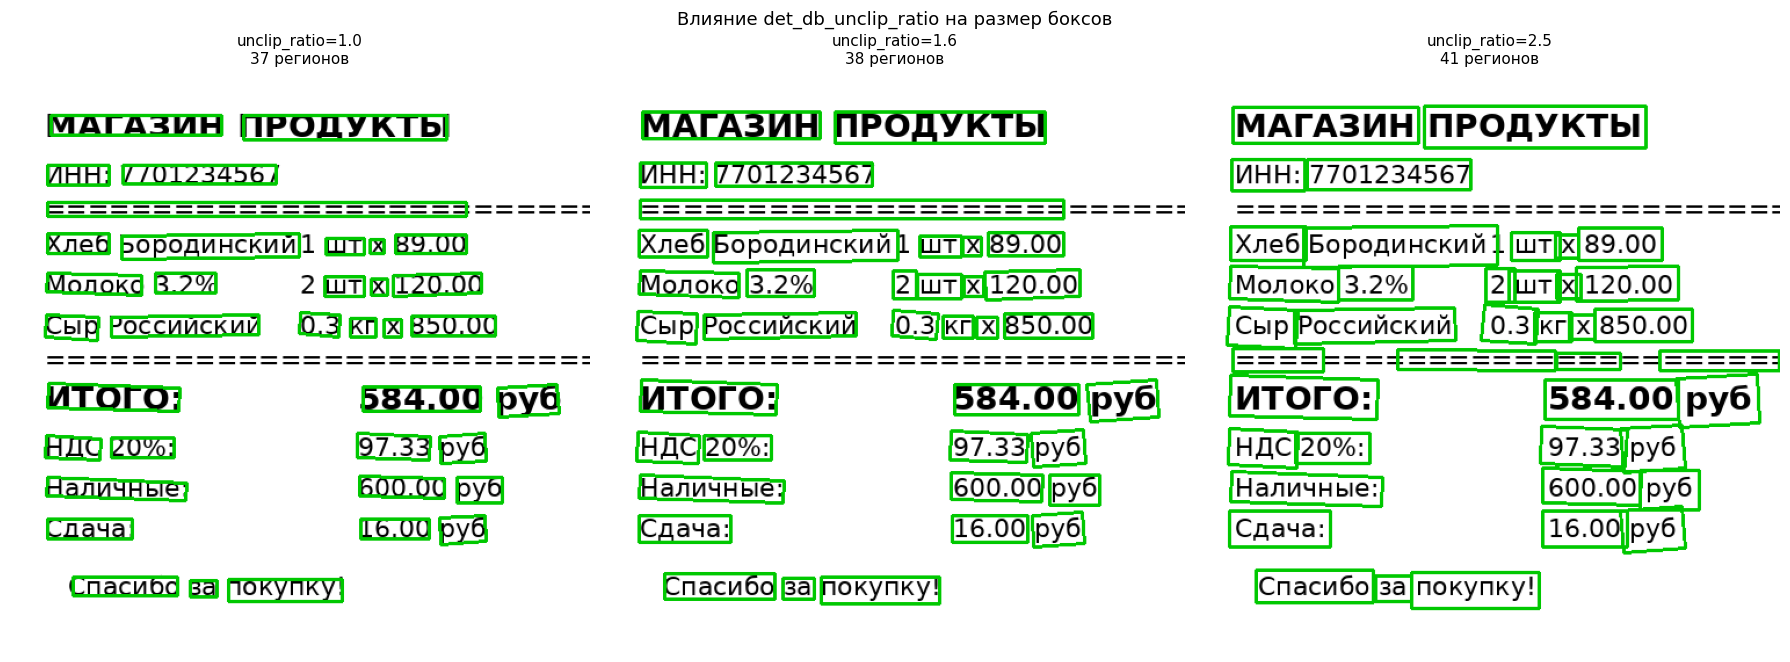

In [ ]:
# Сравниваем разные det_db_unclip_ratio
# Этот параметр управляет расширением контуров после детекции

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, ratio in zip(axes, [1.0, 1.6, 2.5]):
    ocr_tmp = PaddleOCR(
        use_angle_cls=False, lang='ru', use_gpu=False,
        show_log=False, det_db_unclip_ratio=ratio
    )
    res = ocr_tmp.ocr('receipt.png', cls=False)
    vis = img_rgb.copy()

    for line in res[0]:
        bbox, (text, conf) = line
        pts = np.array(bbox, dtype=np.int32)
        cv2.polylines(vis, [pts], True, (0, 200, 0), 2)

    ax.imshow(vis)
    ax.set_title(f'unclip_ratio={ratio}\n{len(res[0])} регионов', fontsize=11)
    ax.axis('off')

plt.suptitle('Влияние det_db_unclip_ratio на размер боксов', fontsize=13)
plt.tight_layout()
plt.show()

## Скорость работы от размера входного изображения

DB-Net это полностью свёрточная сеть и как любая свёрточная архитектура,
она обрабатывает каждый пространственный элемент входа независимо.
Это означает что вычислительная сложность растёт пропорционально площади изображения:
увеличили сторону в 2 раза и количество операций выросло в 4 раза.

Поэтому стоит учитывать баланс качества и скорости, посмотрим на примере:

In [ ]:
import time

# Создаём изображения разного размера
sizes = [320, 640, 1280]
test_images = {}

for size in sizes:
    img = Image.new('RGB', (size, size // 2), color='white')
    draw = ImageDraw.Draw(img)
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", size // 10)

    draw.text((size // 10, size // 5), "Text detection speed test", fill='black', font=font)
    path = f'test_{size}.png'
    img.save(path)
    test_images[size] = path

print(f"{'Размер':<12} {'Время (ms)':<15} {'Регионов':<12} {'Точность'}")
print("-" * 50)

for size, path in test_images.items():
    times = []
    for _ in range(3):
        t0  = time.perf_counter()
        res = ocr_en.ocr(path, cls=False)
        times.append((time.perf_counter() - t0) * 1000)

    dt    = np.mean(times)
    confs = [line[1][1] for line in res[0]] if res[0] else [0]
    print(f"{size}x{size//2:<6} {dt:<15.0f} {len(res[0]):<12} {np.mean(confs):.1%}")


Размер       Время (ms)      Регионов     Точность
--------------------------------------------------
320x160    129             1            99.9%
640x320    160             1            99.7%
1280x640    267             1            100.0%


Как видно время инференса растёт с размером изображения. Для production рекомендуется ресайзить изображения до 640-960px по длинной стороне

## Анализ уверенности распознавания

Статистика уверенности:
  Средняя:      89.0%
  Минимальная:  60.0%
  Максимальная: 99.9%


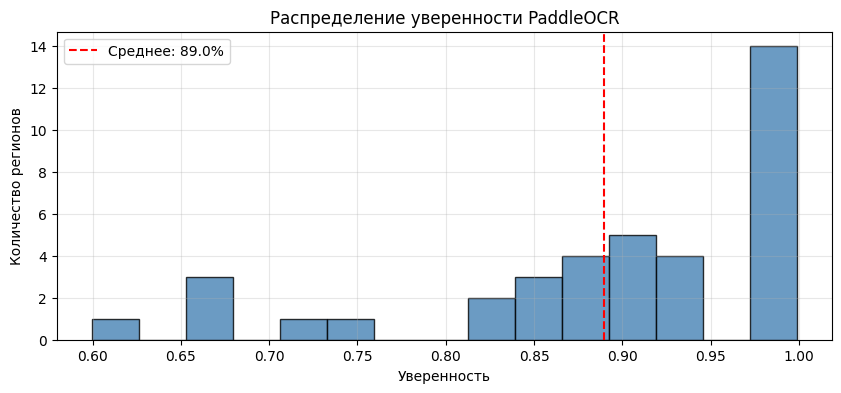


Регионы с уверенностью < 80%:
  'LLLLLLLLLLLLLLLLLE' — 60.0%
  '850.0о' — 75.3%
  'ееееее' — 67.4%
  'иTOгO:' — 72.0%
  '97:33' — 66.7%
  '6оо.0о' — 66.1%


In [ ]:
results = ocr_ru.ocr('receipt.png', cls=True)

confidences = [line[1][1] for line in results[0]]
texts       = [line[1][0] for line in results[0]]

if confidences:
    print(f"Статистика уверенности:")
    print(f"  Средняя:      {np.mean(confidences):.1%}")
    print(f"  Минимальная:  {np.min(confidences):.1%}")
    print(f"  Максимальная: {np.max(confidences):.1%}")

    plt.figure(figsize=(10, 4))
    plt.hist(confidences, bins=15, edgecolor='black', color='steelblue', alpha=0.8)
    plt.axvline(np.mean(confidences), color='red', linestyle='--',
                label=f'Среднее: {np.mean(confidences):.1%}')
    plt.xlabel('Уверенность')
    plt.ylabel('Количество регионов')
    plt.title('Распределение уверенности PaddleOCR')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    threshold = 0.8
    low_conf  = [(t, c) for t, c in zip(texts, confidences) if c < threshold]
    if low_conf:
        print(f"\nРегионы с уверенностью < {threshold:.0%}:")
        for text, conf in low_conf:
            print(f"  '{text}' — {conf:.1%}")

## Изогнутый текст


Изогнутый текст это один из самых показательных стресс-тестов для детектора.
В отличие от наклоненного текста где строка остается прямой,
здесь каждая буква стоит под своим углом и единой прямой линии не существует.

DB-Net в этом случае сталкивается с архитектурным ограничением:
prob map это попиксельная карта вероятностей, а постобработка через
findContours + unclip строит выпуклый контур вокруг всего региона целиком.
Этот контур не может повторить изгиб строки он просто охватывает
все найденные пиксели одним прямоугольником или выпуклым полигоном.

Снижение порогов ``det_db_thresh`` и ``det_db_box_thresh`` помогает детектору
найти больше пикселей текста, но форму бокса это не исправит и
бокс все равно будет прямоугольным вокруг всей дуги целиком.

Посмотрим как справляется PaddleOCR и какие пороги дают лучший результат.

In [ ]:
!wget --no-check-certificate -q "https://ml.gan4x4.ru/wb/ocr/curve_text.jpg"
!wget --no-check-certificate -q "https://ml.gan4x4.ru/wb/ocr/curve_text2.jpg"

[2026/04/05 09:14:08] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
Найдено регионов: 2

Результат:
  [79%] Blackeby
  [92%] OLD SWEET SHOP


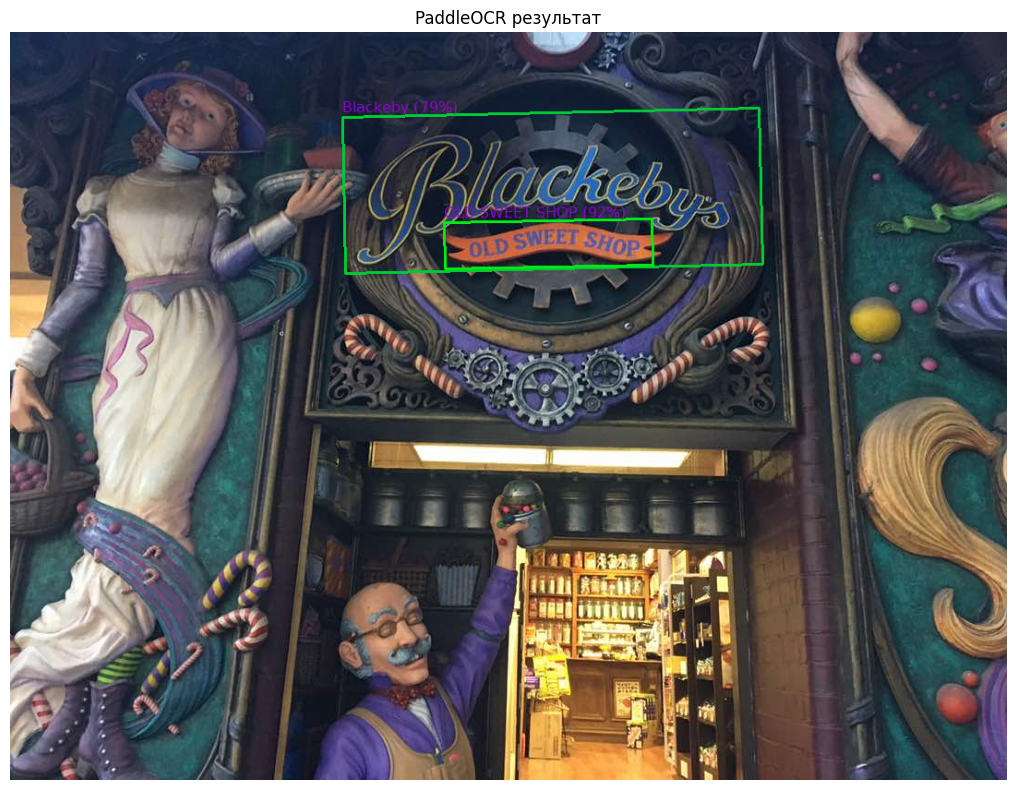

In [ ]:
ocr_sensitive = PaddleOCR(
    lang='en',
    use_gpu=False,
    show_log=False,
    det_db_thresh=0.2,        # порог бинаризации prob map (по умолчанию 0.3)
    det_db_box_thresh=0.3,    # порог уверенности бокса (по умолчанию 0.5)
    det_db_unclip_ratio=2.0,  # расширение контура (по умолчанию 1.5)
)
results_curve = ocr_sensitive.ocr('curve_text.jpg', cls=True)

print(f"Найдено регионов: {len(results_curve[0])}")
print("\nРезультат:")
for line in results_curve[0]:
    bbox, (text, conf) = line
    print(f"  [{conf:.0%}] {text}")

visualize_paddle('curve_text.jpg', results_curve, 'DB-Net на тексте по дуге')

[2026/04/05 09:18:54] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process
Найдено регионов: 8

Результат:
  [73%] E
  [85%] OCEAN 
  [99%] 924
  [84%] CHINAA
  [95%] UNIVERSITY
  [98%] OF
  [95%] mework for person
  [98%] tionaln


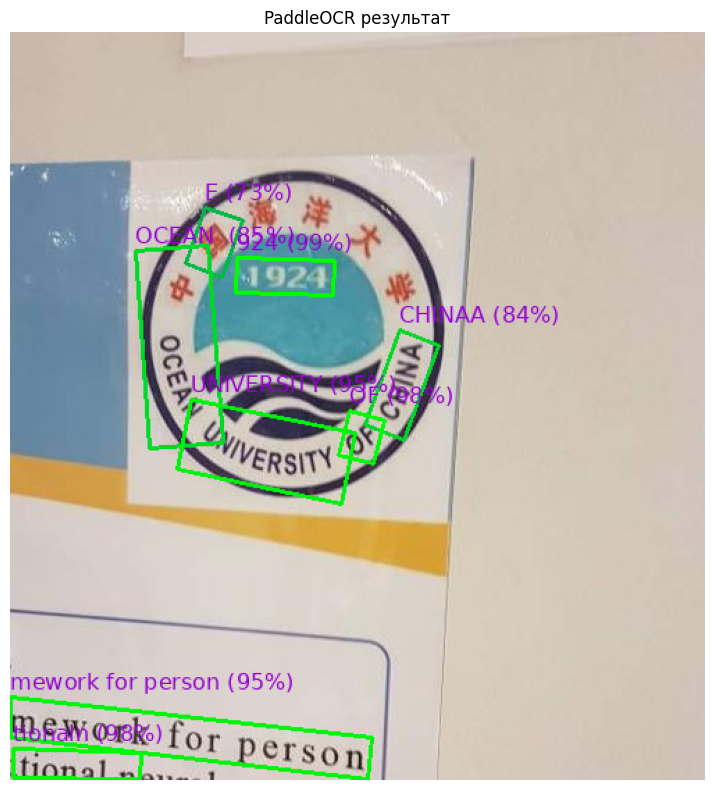

In [ ]:
ocr_sensitive = PaddleOCR(
    lang='en',
    use_gpu=False,
    show_log=False,
    det_db_thresh=0.2,        # порог бинаризации prob map (по умолчанию 0.3)
    det_db_box_thresh=0.3,    # порог уверенности бокса (по умолчанию 0.5)
    det_db_unclip_ratio=2.0,  # расширение контура (по умолчанию 1.5)
)
results_curve = ocr_sensitive.ocr('curve_text2.jpg', cls=True)

print(f"Найдено регионов: {len(results_curve[0])}")
print("\nРезультат:")
for line in results_curve[0]:
    bbox, (text, conf) = line
    print(f"  [{conf:.0%}] {text}")

visualize_paddle('curve_text2.jpg', results_curve, 'DB-Net на тексте по дуге')

## Перевернутый текст

Есть ещё одна важная фишка которая отличает PaddleOCR это классификатор ориентации текста. Это отдельная лёгкая сеть которая определяет повёрнут ли текстовый регион на 180 градусов и автоматически исправляет его перед распознаванием.
В реальных задачах это встречается постоянно: сканы документов загруженные вверх ногами, фото сделанные в портретной ориентации, страницы книг с боковыми сносками. Tesseract и EasyOCR с этим справляются плохо без предобработки.

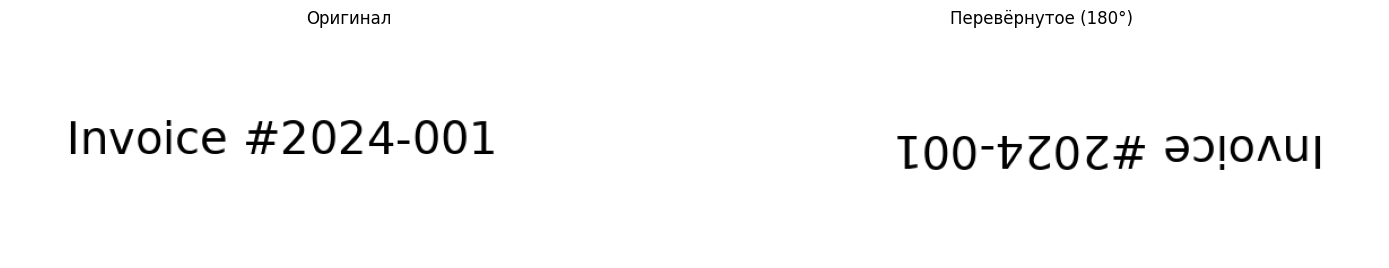

In [ ]:
## Автоматическое исправление ориентации текста

# Создаём нормальное изображение
img = Image.new('RGB', (600, 200), color='white')
draw = ImageDraw.Draw(img)
font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 40)

draw.text((50, 70), "Invoice #2024-001", fill='black', font=font)
img.save('normal.png')

# Переворачиваем на 180 градусов — имитируем скан вверх ногами
img_flipped = img.rotate(180)
img_flipped.save('flipped.png')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(img)
axes[0].set_title('Оригинал')
axes[0].axis('off')
axes[1].imshow(img_flipped)
axes[1].set_title('Перевёрнутое (180°)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Без классификатора ориентации
ocr_no_cls = PaddleOCR(lang='en', use_gpu=False, show_log=False)

# С классификатором ориентации
ocr_with_cls = PaddleOCR(lang='en', use_gpu=False, show_log=False, use_angle_cls=True)

for title, ocr_inst, use_cls in [
    ('Без cls, перевёрнутое',   ocr_no_cls,   False),
    ('С cls, перевёрнутое',     ocr_with_cls, True ),
]:
    path   = 'flipped.png' if 'перевёрнутое' in title else 'normal.png'
    result = ocr_inst.ocr(path, cls=use_cls)

    texts = [line[1][0] for line in result[0]] if result[0] else []
    confs = [line[1][1] for line in result[0]] if result[0] else []
    avg_conf = np.mean(confs) if confs else 0

    print(f"{title}:")
    print(f"  Результат:  {texts}")
    print(f"  Точность:   {avg_conf:.1%}")
    print()

Без cls, перевёрнутое:
  Результат:  []
  Точность:   0.0%

С cls, перевёрнутое:
  Результат:  ['Invoice #2024-001']
  Точность:   99.1%



## Анализ структуры документа





Все три инструмента которые мы рассмотрели умеют читать текст.
Но в реальных задачах часто важно не просто прочитать,
а понять структуру документа: где заголовок, где основной текст,
а где таблица со строками и столбцами.

Именно здесь PaddleOCR показывает свое главное преимущество.
PPStructure это модуль анализа layout документа.
Он умеет определять типы регионов (текст, таблица, изображение, заголовок)
и для таблиц восстанавливать структуру строк и столбцов,
возвращая результат в виде HTML.

Это критически важно для промышленных задач:
обработка счетов и накладных, извлечение данных из медицинских карт,
парсинг банковских выписок, оцифровка форм и анкет.
Во всех этих случаях простой список строк текста бесполезен и
нужна именно структура.

Tesseract имеет базовый layout-анализ через PSM-режимы,
но он не умеет возвращать таблицы в структурированном виде.
EasyOCR не имеет layout-анализа вообще.
PaddleOCR через PPStructure делает это из коробки одной строкой кода.

download https://paddleocr.bj.bcebos.com/ppstructure/models/slanet/en_ppstructure_mobile_v2.0_SLANet_infer.tar to /root/.paddleocr/whl/table/en_ppstructure_mobile_v2.0_SLANet_infer/en_ppstructure_mobile_v2.0_SLANet_infer.tar


100%|██████████| 10.2M/10.2M [00:00<00:00, 18.1MiB/s]


download https://paddleocr.bj.bcebos.com/ppstructure/models/layout/picodet_lcnet_x1_0_fgd_layout_infer.tar to /root/.paddleocr/whl/layout/picodet_lcnet_x1_0_fgd_layout_infer/picodet_lcnet_x1_0_fgd_layout_infer.tar


100%|██████████| 10.1M/10.1M [00:00<00:00, 16.0MiB/s]


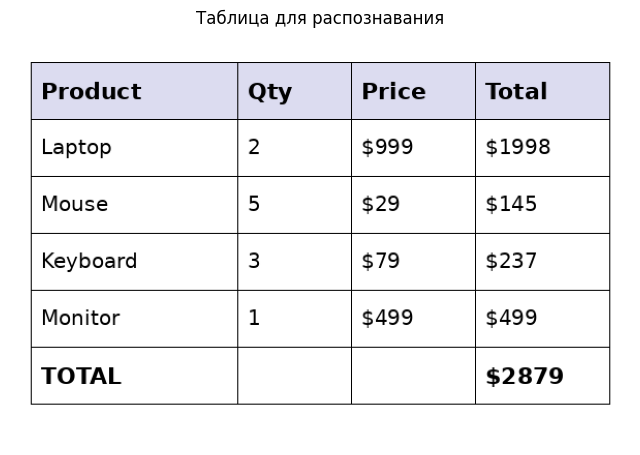

In [ ]:
## Анализ структуры таблицы (PPStructure)

from paddleocr import PPStructure

# PPStructure — расширение PaddleOCR для анализа документов
table_engine = PPStructure(
    lang='en',
    show_log=False,
    image_orientation=False,
)

# Создаём изображение с таблицей
img = Image.new('RGB', (600, 400), color='white')
draw = ImageDraw.Draw(img)

font_h = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 22)
font   = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 20)

# Рисуем таблицу вручную
rows = [
    ["Product",       "Qty", "Price",   "Total"],
    ["Laptop",        "2",   "$999",    "$1998"],
    ["Mouse",         "5",   "$29",     "$145" ],
    ["Keyboard",      "3",   "$79",     "$237" ],
    ["Monitor",       "1",   "$499",    "$499" ],
    ["TOTAL",         "",    "",        "$2879"],
]

col_x  = [30, 230, 340, 460]
row_h  = 55
margin = 30

# Фон заголовка
draw.rectangle([20, margin, 580, margin + row_h], fill=(220, 220, 240))

for r_idx, row in enumerate(rows):
    y = margin + r_idx * row_h
    # Линии строк
    draw.line([(20, y), (580, y)], fill='black', width=1)
    for c_idx, cell in enumerate(row):
        f = font_h if r_idx == 0 or r_idx == len(rows) - 1 else font
        draw.text((col_x[c_idx], y + 15), cell, fill='black', font=f)

# Последняя линия и вертикальные линии
draw.line([(20, margin + len(rows) * row_h), (580, margin + len(rows) * row_h)], fill='black', width=1)
for x in [20, 220, 330, 450, 580]:
    draw.line([(x, margin), (x, margin + len(rows) * row_h)], fill='black', width=1)

img.save('table.png')

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis('off')
plt.title('Таблица для распознавания')
plt.show()

In [ ]:
# Распознаём структуру таблицы
result = table_engine('table.png')

print(f"Найдено регионов: {len(result)}")
for region in result:
    print(f"\nТип региона: {region['type']}")
    if region['type'] == 'table':
        # PPStructure возвращает HTML-представление таблицы
        html = region['res']['html']
        print("HTML таблицы:")
        print(html)

Найдено регионов: 1

Тип региона: table
HTML таблицы:
<html><body><table><thead><tr><td>Product</td><td>Qty</td><td> Price</td><td>Total</td></tr></thead><tbody><tr><td>Laptop</td><td>2</td><td>$999</td><td>$1998</td></tr><tr><td>Mouse</td><td>5</td><td>$29</td><td>$145</td></tr><tr><td>Keyboard</td><td>3</td><td>$79</td><td>$237</td></tr><tr><td> Monitor</td><td>1</td><td>$499</td><td>$499</td></tr><tr><td>TOTAL</td><td></td><td></td><td>$2879</td></tr></tbody></table></body></html>


In [ ]:
# Красиво отображаем HTML таблицу
from IPython.display import HTML, display

for region in result:
    if region['type'] == 'table':
        display(HTML(region['res']['html']))

Product,Qty,Price,Total
Laptop,2,$999,$1998
Mouse,5,$29,$145
Keyboard,3,$79,$237
Monitor,1,$499,$499
TOTAL,,,$2879


## Ограничения PaddleOCR

**Когда PaddleOCR хорош:**
- Английский или китайский язык.  
- Документы смешанного типа: и печатный, и рукописный, и таблицы
- Нужна гибкая настройка порогов детектора DB-Net

**Когда PaddleOCR проигрывает:**
- Одновременная работа с несколькими языками на одном изображении т.к  нет нативной поддержки


## Заключение

Главные выводы:

1. **PaddleOCR = DB-Net + CRNN/SVTR + гибкая конфигурация.** Трёхэтапный pipeline (детекция, классификация угла, распознавание)

2. **Параметры DB-Net доступны напрямую.** `det_db_thresh`, `det_db_box_thresh` и `det_db_unclip_ratio`  именно те параметры, которые мы исследовали в блокноте по детекции текста. Зная механику DB-Net, вы можете осознанно их настраивать.

3. **Для многоязычных сцен EasyOCR удобнее.** PaddleOCR требует создавать отдельный объект для каждого языка, что неудобно когда языки перемешаны на одном изображении.


**Полезные ресурсы:**
- [PaddleOCR GitHub](https://github.com/PaddlePaddle/PaddleOCR)
- [DB-Net paper](https://arxiv.org/abs/1911.08947)
- [PP-OCRv3 technical report](https://arxiv.org/abs/2206.03001)